# MNIST Sprites vs Animal Sprites

This notebook compares the original moving-animal generator with `mnist_sprites`, which keeps the same moving-sprite latent labels and replaces the foreground object with class-balanced MNIST train digits resized to 32x32. The MNIST variant also adds a sequence-level color label.

In [1]:
import sys
from pathlib import Path

repo = Path.cwd().resolve()
if repo.name == "notebooks":
    repo = repo.parent
sys.path.insert(0, str(repo))

import matplotlib.pyplot as plt
import torch

from harpl.data.synthetic_sprites_dataset import MNISTSpriteVideoDataset, SpriteVideoDataset

In [2]:
common = dict(
    data_dir=str(repo / "datasets"),
    split="train",
    output_size=(64, 64),
    seq_len=32,
    num_sequences=16,
    max_sprites=8,
    noise_type="gaussian",
    noise_intensity=0.1,
    noise_on_top=True,
    seed=0,
)

animals = SpriteVideoDataset(sprite_img_dir="animals", **common)
mnist = MNISTSpriteVideoDataset(sprite_img_dir="mnist_sprites", **{**common, "max_sprites": 10})

Computing normalization values using 10000 samples...
Computed normalization values - mean: tensor([0.5007, 0.4950, 0.4929]), std: tensor([0.1247, 0.1188, 0.1214])
Computing normalization values using 10000 samples...
Computed normalization values - mean: tensor([0.4961, 0.4928, 0.4919]), std: tensor([0.1118, 0.1129, 0.1163])


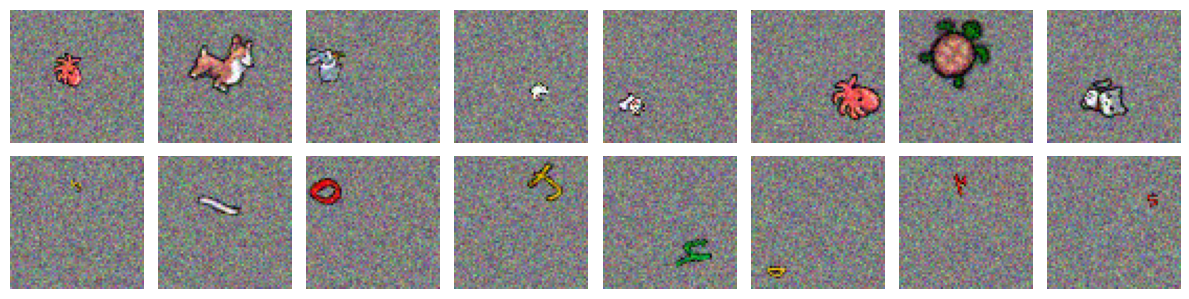

In [6]:
def denorm(video, dataset):
    if dataset.grayscale:
        return torch.clamp(video * dataset.std + dataset.mean, 0, 1)
    mean = dataset.mean.view(1, 3, 1, 1)
    std = dataset.std.view(1, 3, 1, 1)
    return torch.clamp(video * std + mean, 0, 1)

def first_frame(dataset, idx):
    video, labels = dataset[idx]
    frame = denorm(video, dataset)[0].permute(1, 2, 0).cpu()
    return frame, labels

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for row, dataset, title in [(0, animals, "animals"), (1, mnist, "mnist_sprites")]:
    for col in range(8):
        frame, labels = first_frame(dataset, col)
        axes[row, col].imshow(frame)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(title)
plt.tight_layout()

In [4]:
animal_video, animal_labels = animals[0]
mnist_video, mnist_labels = mnist[0]

print("animals seq labels [sprite_idx, rotation_direction]:", animal_labels[0].tolist())
print("mnist_sprites seq labels [digit, color, rotation_direction]:", mnist_labels[0].tolist())
print("dense label names are unchanged: xdir, ydir, zdir, x-position bin, y-position bin, z-position bin, orientation")
print("continuous dense label shape animals:", tuple(animal_labels[3].shape))
print("continuous dense label shape mnist_sprites:", tuple(mnist_labels[3].shape))

animals seq labels [sprite_idx, rotation_direction]: [4, 1]
mnist_sprites seq labels [digit, color, rotation_direction]: [5, 3, 2]
dense label names are unchanged: xdir, ydir, zdir, x-position bin, y-position bin, z-position bin, orientation
continuous dense label shape animals: (32, 8)
continuous dense label shape mnist_sprites: (32, 8)
